# Lecture 3 - Black & Scholes theory

## Exercise
Black-Scholes theory assumes that the time evolution of the asset price is stochastic and exhibits geometric Brownian motion (GBM) with constant risk-free interest rate $r$ and volatility $\sigma$.

Black-Scholes analytic solution  for the price at time t<T:
- European Call-option price:
$$ C\left[ S(t),t \right] = S(t) N(d_1) -K e^{-r(T-t)} N(d_2) $$
- European Put-option price:
$$ P\left[ S(t),t \right] = S(t) \left[ N(d_1)-1\right] -K e^{-r(T-t)} \left[ N(d_2)-1\right]$$

where 
$$d_1 = \frac{1}{\sigma\sqrt{T-t}}\left[ \ln \left( \frac{S(t)}{K} \right) + \left( r+\frac{\sigma^2}{2} (T-t) \right)\right]$$

where $d_2 = d_1 - \sigma\sqrt{T-t}$, and where
$$ N(x) = \int_{-\infty}^{x} dz \, e^{-\frac{z^2}{2}} = \frac{1}{2} \left[ 1+ {\rm erf} \left( \frac{x}{\sqrt{2}}\right) \right]$$
is the cumulative of Gaussian $\sim \mathcal{N}(\mu=0,\sigma^2=1)$,
and where
$${\rm erf}(x) = \frac{2}{\sqrt{\pi}}\int_{0}^{x} dz \, e^{-z^2}$$

By using the following parameters: 
- asset price at $t=0$: $S(0)=100$
- delivery time: $T=1$
- strike price: $K=100$
- risk-free interest rate: $r=0.1$
- volatility: $\sigma=0.25$

compute at time $t=0$ **via Monte Carlo** the European call-option price, $C[S(0),0]$, and put-option price, $P[S(0),0]$:

1.  By sampling **directly** the final asset price $S(T)$ for a $GBM(r,\sigma^2)$
2.  By sampling the discretized $GBM(r,\sigma^2)$ path of the asset price 
dividing $[0,T]$ in $10^2$ time intervals: $S(0)$, $S(t_1)$, $S(t_2)$, ... up to $S(t_{100}=T=1)$


Remember that given an asset price $S\sim GBM(\mu,\sigma^2)$, with initial value $S(0)$, then
    $$S(t) = S(0) \exp\left[ \left(\mu-\frac{1}{2}\sigma^2\right)t+\sigma W(t)\right]$$
    where $W(t)\sim\mathcal{N}(0,t)$.
    Moreover, since the increments of $W$ are independent and normally distributed, the simple recursive procedure for sampling discretized values of $S\sim GBM(\mu,\sigma^2)$ at $t_1 < t_2 < … < t_n$ is:
$$
S(t_{i+1}) = S(t_i) \exp\left[ \left(\mu-\frac{1}{2}\sigma^2\right)(t_{i+1}-t_i)
    +\sigma Z_{i+1}\sqrt{t_{i+1}-t_i}\right]
$$
with $Z_i \sim \mathcal{N}(0,1)$.

Make four pictures for the estimation of the European call-option prices, $C[S(0),0]$ (direct and discretized), and put-option prices, $P[S(0),0]$ (direct and discretized), with their uncertainties  with a large number of asset prices at time $t=T$, say $M\ge 10^4$, as a function of the number of blocks, $N$. As usual, in computing statistical uncertainties, use data blocking.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
import matplotlib as mpl
from numpy import exp
from numpy.lib.scimath import log, sqrt
from scipy.special import erf

plt.style.use('default')
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6



## Background and solution

### Wiener process
In 1923 Norbert Wiener constructed a rigourous theory for the Brownian motion (i.e. the random motion of particles suspended in a medium). A Wiener process $ \{W(t),t\geq 0 \}$ is a stochastic process that satisfies the properties of:
1. $W(0)=0$
2. The increments $W(t)-W(s)$ are stationary and independent
3. For $t>s$ $W(t)-W(s)$ has a gaussian distribution $\mathcal{N}(0;t-s)$.

The condition of stationariety implies that the probability distribution for $W(t)-W(s)$ (for $t>s$) depends only on the difference in time $t-s$. 

### Markov assumption 
A key-point of the Black-Scholes theory is the Markov assumption, which says that the future evolution of an asset price depends exclusively on its current value rather than its historical trajectory. In the context of stochastic calculus, this implies that the conditional probability distribution of future prices is determined only by the present state
$$
P(S_{t_{n+1}} | S_{t_n}, S_{t_{n-1}}, \dots, S_{t_0}) = P(S_{t_{n+1}} | S_{t_n})
$$
The Markov property serves as a direct theoretical counterpart to the "Efficient Market Hypothesis", which tells us that an ideal market knows new information so efficiently that current prices always contain all available data regarding its development. This efficiency is supported by the existence of a liquid market, characterized by an environment where any investor can easily buy/sell a financial product at any time. Because a highly liquid market allows investors to move their assets consistently, it increases the overall security of the market. In such an environment, any predictable pattern or residual memory within the price history would be immediately exploited by rational agents causing the profitable opportunity to vanish as prices adjust.

Consequently, these market dynamics limit correlations to nearly instantaneous time scales, providing the rigorous justification for employing stochastic processes with independent increments, such as the Wiener process, to model financial returns.

### Modeling with Stochastic Differential Equations (SDE)
To define the evolution of an asset price $S(t)$, we combine two distinct components. Firstly a deterministic drift, similar to a bank account with continuous compounding, where $dS(t) = \mu S(t) dt$. The latter is the stochastic volatility, a noise term proportional to the current price, represented by $\sigma S(t) dW(t)$.
Summing these gives the SDE for Geometric Brownian Motion
$$
dS(t) = \mu S(t) dt + \sigma S(t) dW(t)
$$
In a risk-neutral world (condition of the Black-Scholes formula), the drift $\mu$ is replaced by the risk-free interest rate $r$.
### Numerical Solution: Direct vs. Discretized Sampling
We used two properties of the Wiener process to perform Monte Carlo simulations. 
#### Direct Sampling
Since $W(T)$ is simply a Gaussian variable $\mathcal{N}(0,T)$, we can jump straight to the final price at the delivery time $T$:$$S(T) = S(0) \exp\left[ \left(r-\frac{1}{2}\sigma^2\right)T+\sigma Z\sqrt{T}\right]$$
#### Discretized Path
If we need to monitor the price at intermediate times (relevant for "Exotic" options), we divide $[0, T]$ into $n$ steps. Because the increments are independent, we can recursively sample:$$S(t_{i+1}) = S(t_i) \exp\left[ \left(r-\frac{1}{2}\sigma^2\right)\Delta t + \sigma Z_{i+1}\sqrt{\Delta t}\right]$$where $\Delta t = t_{i+1} - t_i$.Both methods are exact for GBM, meaning the discretized path will not introduce a systematic discretization error compared to the analytic distribution, provided the underlying assumptions of constant $r$ and $\sigma$ hold.

### Implementation
The code initializes a stochastic simulation using $M = 10^5$ total asset price realizations, divided into $N = 100$ blocks ($L = 10^3$ throws per block) to implement the data blocking method. The financial parameters are set to the values written before.

For the two pricing methods:

1. **Direct**: in the first simulation block, the code samples the final asset price $S(T)$ in a single step. For each iteration, it generates one Gaussian variable to compute the final price and evaluates the discounted payoffs:
- Call Payoff: $e^{-rT} \max(0, S(T) - K)$
- Put Payoff: $e^{-rT} \max(0, K - S(T))$
2. **Discretized path**: in the second simulation block, the interval $[0, T]$ is divided into $100$ sub-intervals of length $\Delta t = T/100$. The price is evolved recursively:$$S(t_{i+1}) = S(t_i) \exp\left[ \left(r - \frac{1}{2}\sigma^2\right)\Delta t + \sigma Z_{i+1} \sqrt{\Delta t} \right]$$This confirms the exact nature of GBM discretization, as the final price $S(T)$ reached through 100 steps should, on average, converge to the same value as the direct sampling method.

### Black & Scholes analytic solution
Here is a Python cell that computes the analytic solution of the Black & Scholes theory, we are going to use this as a comparison value.

In [2]:
# data
S0 = 100.
K = 100.
T = 1.
r = 0.1
sigma = 0.25
t=0

def N(x):
    return 0.5 * (1. + erf(x / sqrt(2.)))

def black_scholes(S0, K, T, r, sigma):
    d1 = 1./(sigma * sqrt(T)) * (log(S0 / K) + (r + (sigma**2) / 2.) * T)
    d2 = d1 - sigma * sqrt(T)
    C = S0 * N(d1) - K * exp(-r * T) * N(d2)
    P = S0 *(N(d1) - 1.) - K * exp(-r * T) * (N(d2)-1.)
    return C, P

if __name__ == "__main__":
    call, put = black_scholes(S0, K, T, r, sigma)
    print(" == BLACK-SCHOLES ==")
    print("call: ", call)
    print("put: ", put)

 == BLACK-SCHOLES ==
call:  14.975790778311286
put:  5.4595325819072364


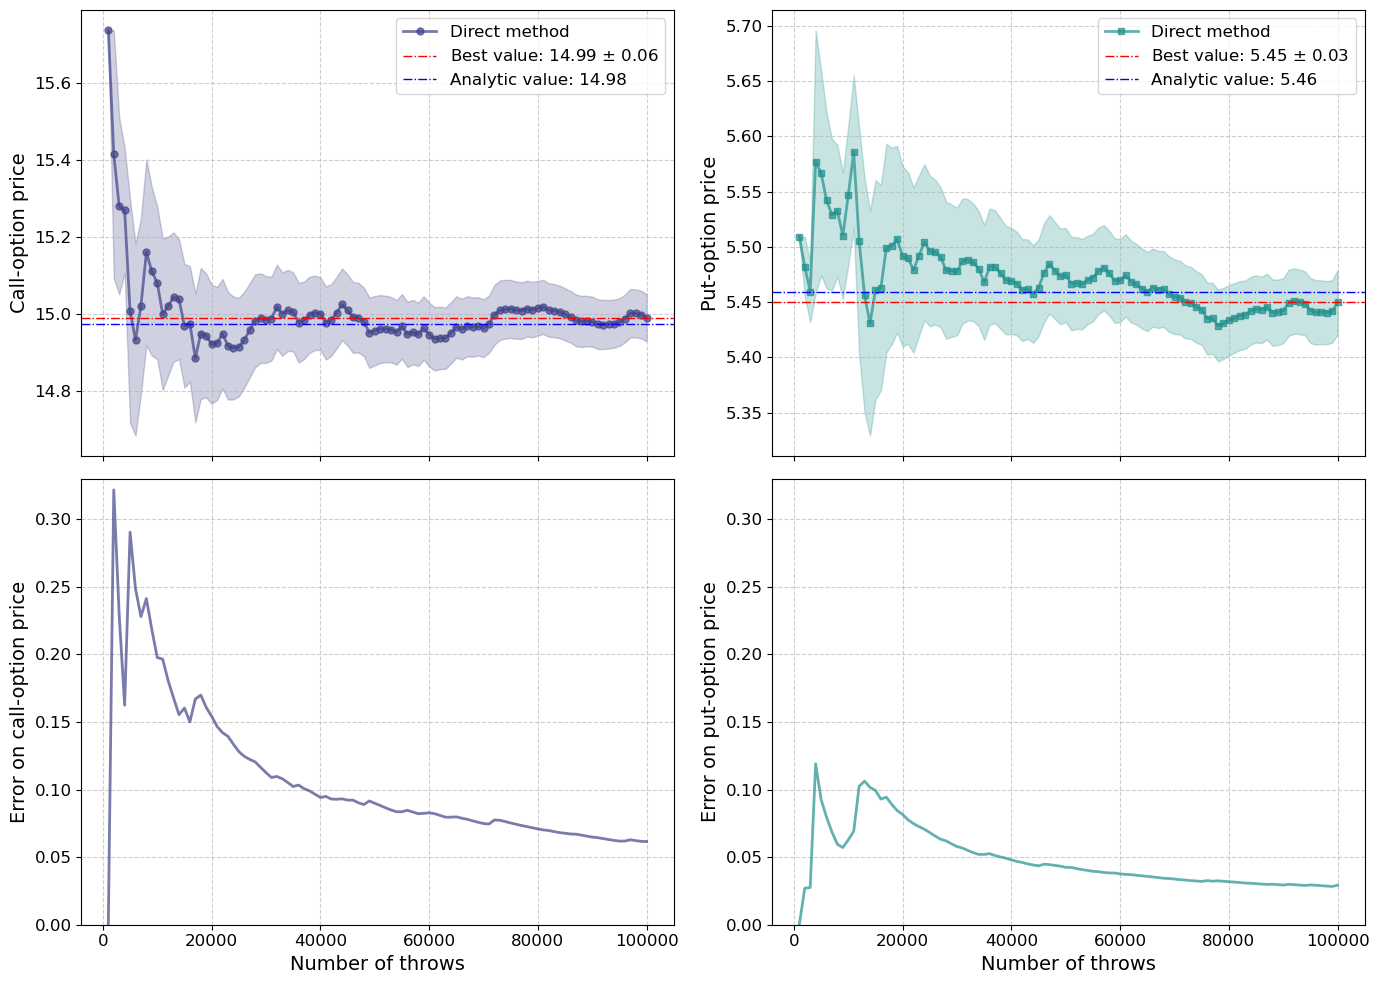

In [10]:
file1 = "output_call.data"
file2 = "output_put.data"
x1, y1, error1 = np.loadtxt(file1, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x2, y2, error2 = np.loadtxt(file2, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x3, y3 = np.loadtxt(file1, usecols=(0, 2), delimiter='\t', unpack=True)
x4, y4 = np.loadtxt(file2, usecols=(0, 2), delimiter='\t', unpack=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=100)

viridis = plt.cm.viridis
color_call = viridis(0.2)    
color_put = viridis(0.5)   
ref_color = 'red'
ref_color_2 = 'blue'

axes[0, 0].plot(x1, y1, 'o-', color=color_call, alpha=0.7, markersize=5,label='Direct method')
axes[0, 0].fill_between(x1, y1-error1, y1+error1,
                       color=color_call, alpha=0.25)
axes[0, 0].set_ylabel('Call-option price')
axes[0, 0].axhline(y=y1[99], color=ref_color, linestyle='-.', linewidth=1, 
                  label=rf'Best value: {y1[-1]:.2f} $\pm$ {error1[-1]:.2f}')
axes[0, 0].axhline(y=call, color='b', linestyle='-.', linewidth=1, label=rf'Analytic value: {call:.2f}')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle='--', alpha=0.6)
axes[0, 0].tick_params(axis='x', labelbottom=False)

axes[0, 1].plot(x2, y2, 's-', color=color_put, alpha=0.7, markersize=5,label='Direct method')
axes[0, 1].fill_between(x2, y2-error2, y2+error2,
                       color=color_put, alpha=0.25)
axes[0, 1].set_ylabel('Put-option price')
axes[0, 1].axhline(y=y2[99], color=ref_color, linestyle='-.', linewidth=1,
                   label=rf'Best value: {y2[-1]:.2f} $\pm$ {error2[-1]:.2f}')
axes[0, 1].axhline(y=put, color='b', linestyle='-.', linewidth=1, label=rf'Analytic value: {put:.2f}')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', labelbottom=False)
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# Standard Monte Carlo - errore
axes[1, 0].plot(x3, y3, '-', color=color_call, alpha=0.7)
axes[1, 0].set_xlabel('Number of throws')
axes[1, 0].set_ylabel('Error on call-option price')
axes[1, 0].set_ylim([0, 0.33])
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# Importance Sampling - errore
axes[1, 1].plot(x4, y4, '-', color=color_put, alpha=0.7)
axes[1, 1].set_xlabel('Number of throws')
axes[1, 1].set_ylabel('Error on put-option price')
axes[1, 1].set_ylim([0, 0.33])
axes[1, 1].grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


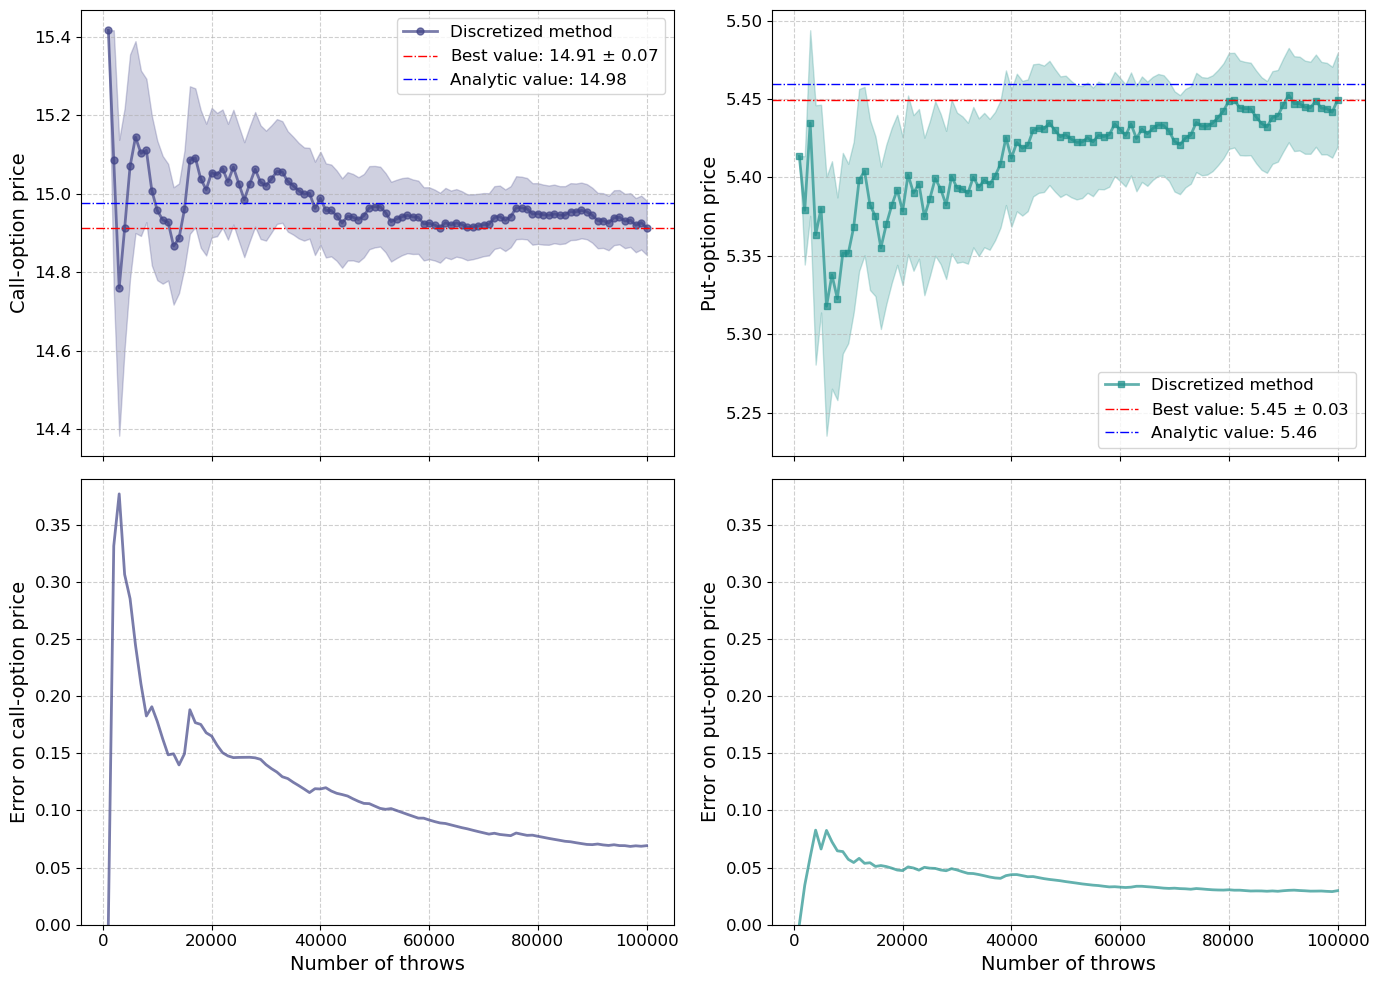

In [11]:
file1 = "output_call_discretized.data"
file2 = "output_put_discretized.data"
x1, y1, error1 = np.loadtxt(file1, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x2, y2, error2 = np.loadtxt(file2, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x3, y3 = np.loadtxt(file1, usecols=(0, 2), delimiter='\t', unpack=True)
x4, y4 = np.loadtxt(file2, usecols=(0, 2), delimiter='\t', unpack=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=100)

viridis = plt.cm.viridis
color_call = viridis(0.2)    
color_put = viridis(0.5)   
ref_color = 'red'
ref_color_2 = 'blue'

axes[0, 0].plot(x1, y1, 'o-', color=color_call, alpha=0.7, markersize=5,label='Discretized method')
axes[0, 0].fill_between(x1, y1-error1, y1+error1,
                       color=color_call, alpha=0.25)
axes[0, 0].set_ylabel('Call-option price')
axes[0, 0].axhline(y=y1[99], color=ref_color, linestyle='-.', linewidth=1,
                   label=rf'Best value: {y1[-1]:.2f} $\pm$ {error1[-1]:.2f}')
axes[0, 0].axhline(y=call, color='b', linestyle='-.', linewidth=1, label=rf'Analytic value: {call:.2f}')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle='--', alpha=0.6)
axes[0, 0].tick_params(axis='x', labelbottom=False)

axes[0, 1].plot(x2, y2, 's-', color=color_put, alpha=0.7, markersize=5,label='Discretized method')
axes[0, 1].fill_between(x2, y2-error2, y2+error2,
                       color=color_put, alpha=0.25)
axes[0, 1].set_ylabel('Put-option price')
axes[0, 1].axhline(y=y2[99], color=ref_color, linestyle='-.', linewidth=1,
                   label=rf'Best value: {y2[-1]:.2f} $\pm$ {error2[-1]:.2f}')
axes[0, 1].axhline(y=put, color='b', linestyle='-.', linewidth=1, label=rf'Analytic value: {put:.2f}')
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.6)
axes[0, 1].tick_params(axis='x', labelbottom=False)

# Standard Monte Carlo - errore
axes[1, 0].plot(x3, y3, '-', color=color_call, alpha=0.7)
axes[1, 0].set_xlabel('Number of throws')
axes[1, 0].set_ylabel('Error on call-option price')
axes[1, 0].set_ylim([0, 0.39])
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# Importance Sampling - errore
axes[1, 1].plot(x4, y4, '-', color=color_put, alpha=0.7)
axes[1, 1].set_xlabel('Number of throws')
axes[1, 1].set_ylabel('Error on put-option price')
axes[1, 1].set_ylim([0, 0.39])
axes[1, 1].grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
